<h1 style="text-align: center;">Individual Assignment 1 - Part 1</h1>
<h3 style="text-align: center;">Case Studies for Data Science - semester 2 2026</h3> 
<h4 style="text-align: center;"> Rose Munro s4054011 </h4>


In [ ]:
#TODO: Load Libraries
import pandas as pd
from pathlib import Path 
import re
import numpy as np
import matplotlib.pyplot as plt
#import sklearn TODO: select models
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import train_test_split


In [21]:
#Using 2021 Census data as most current data with AEDC data match
Path.cwd()

WindowsPath('c:/Users/Rose3/OneDrive/Documents/2026 - semester 2/Case Studies for Data Science/Individual A1/Ind A1 Repo')

#### Load AEDC Data (Target)

In [22]:
aedc_target = pd.read_excel("data\\aedc_target.xlsx",
              sheet_name = "Target_sorted",
              dtype={"Code": str},
              na_values="*")

In [23]:
aedc_target.info()

<class 'pandas.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Code             2210 non-null   str    
 1   Name             2210 non-null   str    
 2   #Valid_Scores    2210 non-null   int64  
 3   #Dev_Vulnerable  2138 non-null   float64
 4   %Dev_Vulnerable  2138 non-null   float64
dtypes: float64(2), int64(1), str(2)
memory usage: 86.5 KB


In [24]:
# aedc_target.tail(10)
aedc_target.tail(10)

,Code,Name,#Valid_Scores,#Dev_Vulnerable,%Dev_Vulnerable
2200,801101135,Coombs,70,7.0,10.000000
2201,801101136,Denman Prospect,53,11.0,20.754717
2202,801101137,Molonglo,0,NaN,NaN
2203,801101139,Wright,53,6.0,11.320755
2204,801101145,Molonglo - East,0,NaN,NaN
2205,801101146,Whitlam,0,NaN,NaN
2206,801111140,ACT - South West,8,NaN,NaN
2207,801111141,Namadgi,0,NaN,NaN
2208,901031003,Jervis Bay,5,NaN,NaN
2209,901041004,Norfolk Island,24,3.0,12.500000


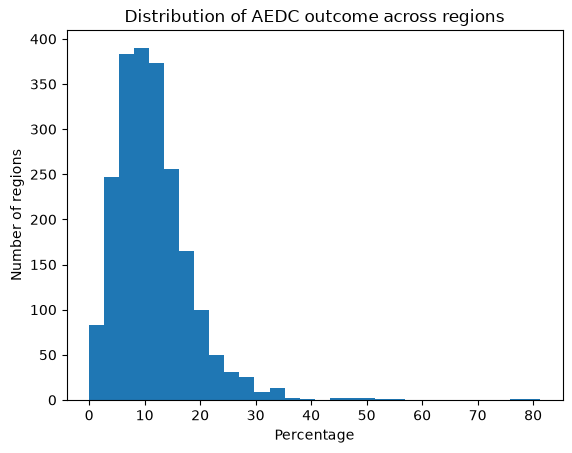

In [25]:
aedc_target["%Dev_Vulnerable"].plot.hist(bins=30)
plt.xlabel("Percentage")
plt.ylabel("Number of regions")
plt.title("Distribution of AEDC outcome across regions")
plt.show()

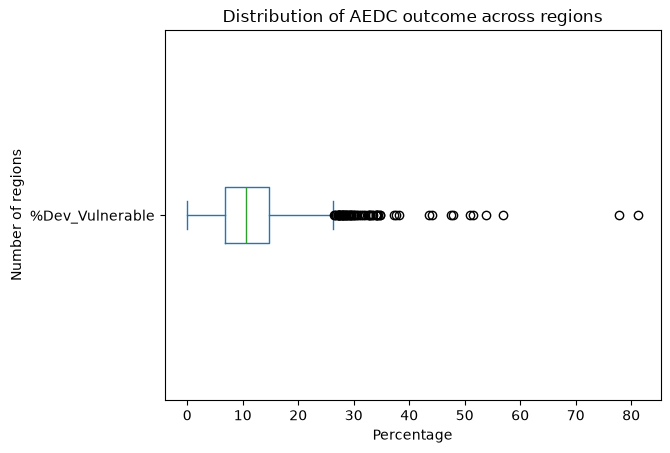

In [26]:
aedc_target["%Dev_Vulnerable"].plot.box(vert=False)
plt.xlabel("Percentage")
plt.ylabel("Number of regions")
plt.title("Distribution of AEDC outcome across regions")
plt.show()

---

#### Load Australian Bureau of Statistics Data


In [27]:
ABS_census_features = pd.read_excel("data\\ABS_census_features.xlsx",
              sheet_name = "Features",
              dtype={"Code": str})

In [28]:
ABS_census_features.head()

,Code,Median_tot_hhd_inc_weekly,Median_tot_prsnl_inc_weekly,Median_mortgage_repay_monthly,Median_rent_weekly,Average_num_psns_per_bedroom,Average_household_size,High_yr_schl_comp_Yr_12_eq_P,High_yr_schl_comp_Yr_10_eq_P,P_Tot_Emp_Tot,P_Tot_Unemp_Tot,Tot_Indigenous_%
0,101021007,1429,760,1732,330,0.8,2.2,1832,897,2013,68,0.024637
1,101021008,1989,975,1950,350,0.8,2.6,3569,1567,4315,198,0.072443
2,101021009,1703,996,1700,330,0.9,2.1,5739,1793,6247,270,0.034738
3,101021010,1796,1104,1700,310,0.9,2.1,2749,729,2922,108,0.033235
4,101021012,3014,1357,2300,430,0.8,2.9,6681,1748,7398,170,0.027228


In [29]:
ABS_census_features.info()

<class 'pandas.DataFrame'>
RangeIndex: 2472 entries, 0 to 2471
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code                           2472 non-null   str    
 1   Median_tot_hhd_inc_weekly      2472 non-null   int64  
 2   Median_tot_prsnl_inc_weekly    2472 non-null   int64  
 3   Median_mortgage_repay_monthly  2472 non-null   int64  
 4   Median_rent_weekly             2472 non-null   int64  
 5   Average_num_psns_per_bedroom   2472 non-null   float64
 6   Average_household_size         2472 non-null   float64
 7   High_yr_schl_comp_Yr_12_eq_P   2472 non-null   int64  
 8   High_yr_schl_comp_Yr_10_eq_P   2472 non-null   int64  
 9   P_Tot_Emp_Tot                  2472 non-null   int64  
 10  P_Tot_Unemp_Tot                2472 non-null   int64  
 11  Tot_Indigenous_%               2472 non-null   float64
dtypes: float64(3), int64(8), str(1)
memory usage: 231.9 KB


#### Merge Target and features (join on SA2 code)

In [30]:
df = pd.merge(ABS_census_features, aedc_target, how="inner", on="Code")

In [31]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2210 entries, 0 to 2209
Data columns (total 16 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Code                           2210 non-null   str    
 1   Median_tot_hhd_inc_weekly      2210 non-null   int64  
 2   Median_tot_prsnl_inc_weekly    2210 non-null   int64  
 3   Median_mortgage_repay_monthly  2210 non-null   int64  
 4   Median_rent_weekly             2210 non-null   int64  
 5   Average_num_psns_per_bedroom   2210 non-null   float64
 6   Average_household_size         2210 non-null   float64
 7   High_yr_schl_comp_Yr_12_eq_P   2210 non-null   int64  
 8   High_yr_schl_comp_Yr_10_eq_P   2210 non-null   int64  
 9   P_Tot_Emp_Tot                  2210 non-null   int64  
 10  P_Tot_Unemp_Tot                2210 non-null   int64  
 11  Tot_Indigenous_%               2210 non-null   float64
 12  Name                           2210 non-null   str    
 13 

---

#### Preprocessing

----

----